c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall 

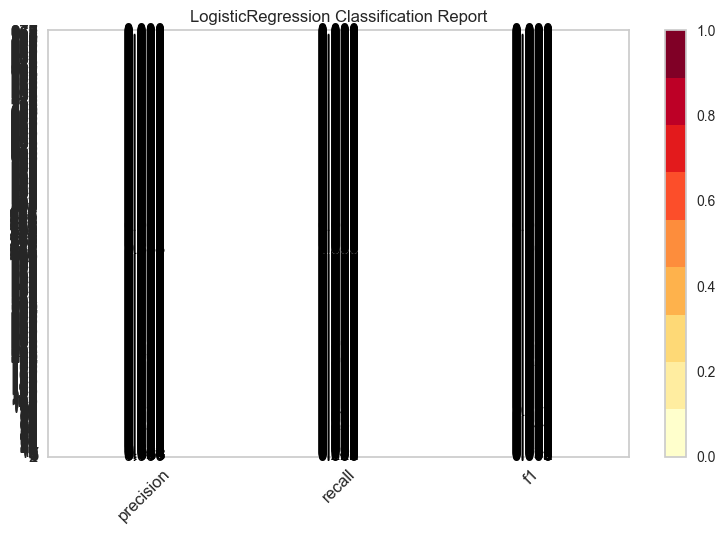

<Axes: title={'center': 'LogisticRegression Classification Report'}>

In [11]:
# pip install yellowbricks
from yellowbrick.classifier import ClassificationReport
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
visualizer = ClassificationReport(model)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

In [12]:
# pip install --force-reinstall yellowbrick


In [4]:
import pandas as pd
from yellowbrick.datasets import load_bikeshare

X, y = load_bikeshare()
print(X.head())

Matplotlib is building the font cache; this may take a moment.


   season  year  month  hour  holiday  weekday  workingday  weather  temp  \
0       1     0      1     0        0        6           0        1  0.24   
1       1     0      1     1        0        6           0        1  0.22   
2       1     0      1     2        0        6           0        1  0.22   
3       1     0      1     3        0        6           0        1  0.24   
4       1     0      1     4        0        6           0        1  0.24   

   feelslike  humidity  windspeed  
0     0.2879      0.81        0.0  
1     0.2727      0.80        0.0  
2     0.2727      0.80        0.0  
3     0.2879      0.75        0.0  
4     0.2879      0.75        0.0  


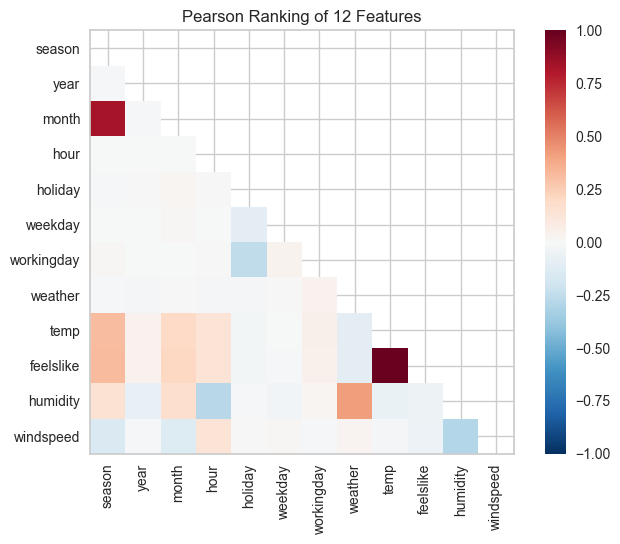

<Axes: title={'center': 'Pearson Ranking of 12 Features'}>

In [5]:
from yellowbrick.features import Rank2D

visualizer = Rank2D(algorithm="pearson")
visualizer.fit_transform(X)
visualizer.show()

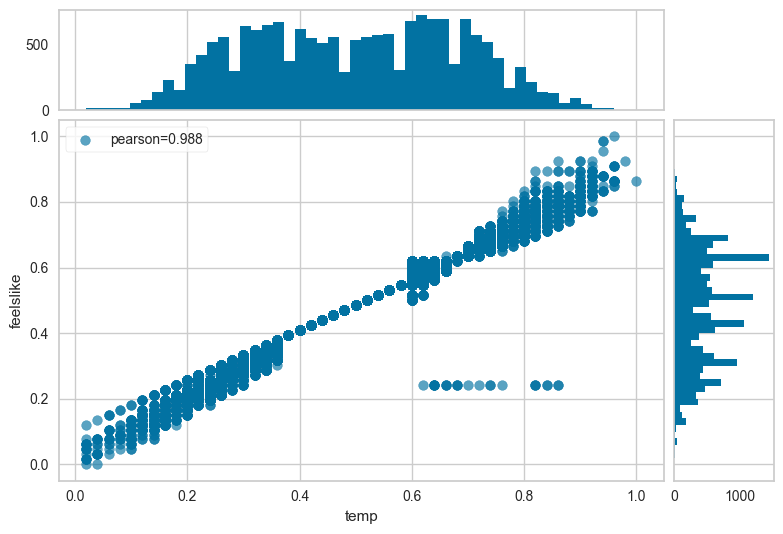

<Axes: xlabel='temp', ylabel='feelslike'>

In [6]:
from yellowbrick.features import JointPlotVisualizer

visualizer = JointPlotVisualizer(columns=['temp', 'feelslike'])
visualizer.fit_transform(X, y)
visualizer.show()

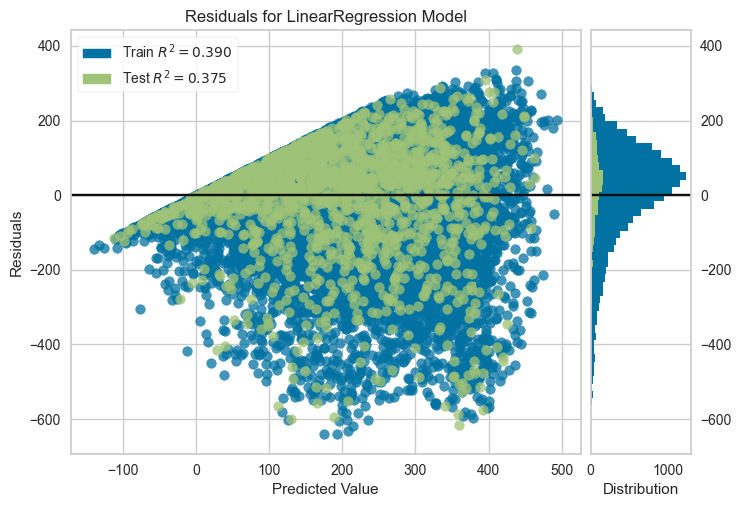

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [7]:
from yellowbrick.regressor import ResidualsPlot
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1
)

visualizer = ResidualsPlot(LinearRegression())
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\utils\deprecation.py:110: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


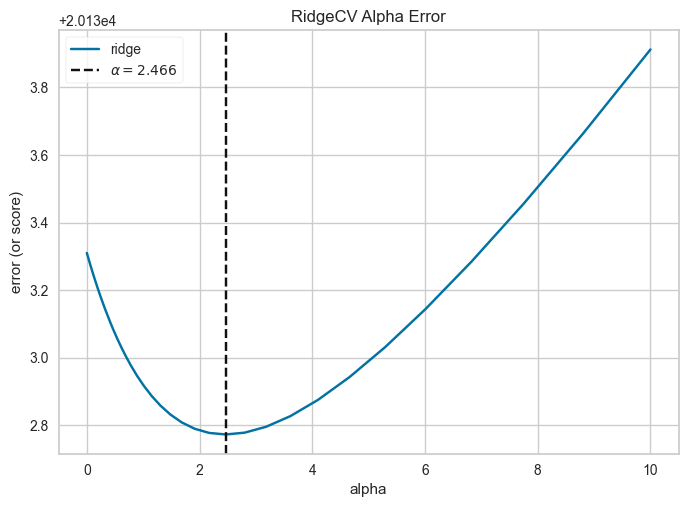

<Axes: title={'center': 'RidgeCV Alpha Error'}, xlabel='alpha', ylabel='error (or score)'>

In [8]:
import numpy as np

from sklearn.linear_model import RidgeCV
from yellowbrick.regressor import AlphaSelection

alphas = np.logspace(-10, 1, 200)
visualizer = AlphaSelection(RidgeCV(alphas=alphas))
visualizer.fit(X, y)
visualizer.show()

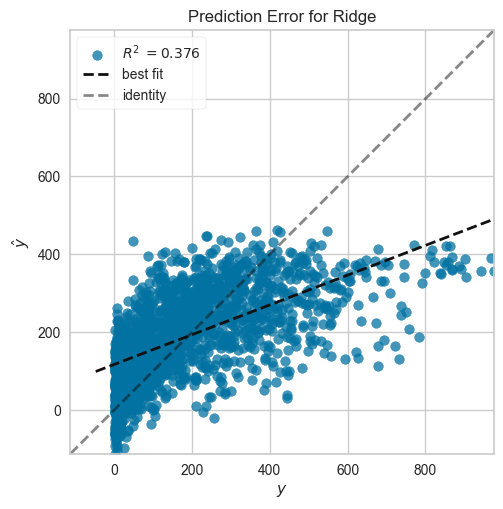

<Axes: title={'center': 'Prediction Error for Ridge'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [9]:
from sklearn.linear_model import Ridge
from yellowbrick.regressor import PredictionError

visualizer = PredictionError(Ridge(alpha=3.181))
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# Feature Analysis


## Rank2D

The rank1d and rank2d plots show pairwise rankings of features to help you detect relationships. More about :doc:`api/features/rankd`.

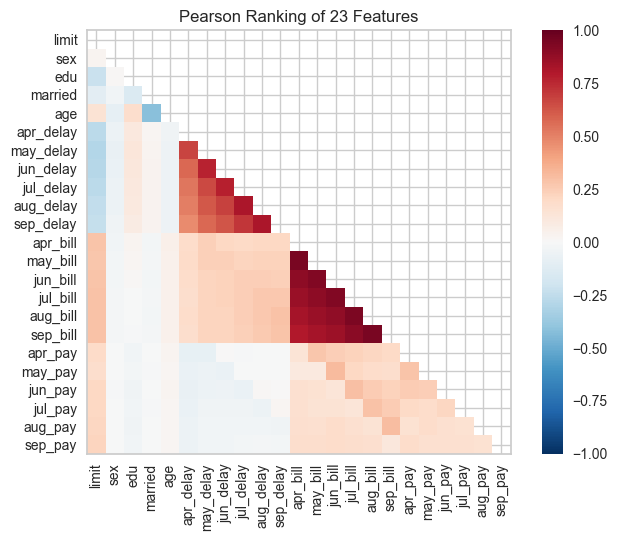

In [27]:
    from yellowbrick.features import rank2d
    from yellowbrick.datasets import load_credit


    X, _ = load_credit()
    visualizer = rank2d(X)

## Parallel Coordinates

The parallel_coordinates plot is a horizontal visualization of instances, disaggregated by the features that describe them. More about :doc:`api/features/pcoords`.

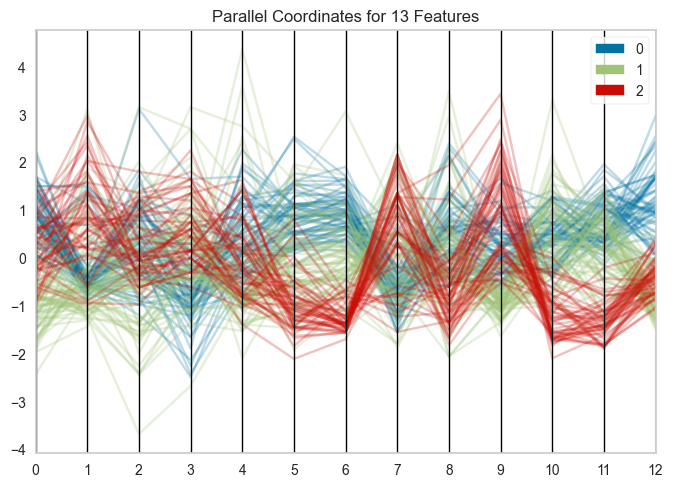

In [26]:
    from sklearn.datasets import load_wine
    from yellowbrick.features import parallel_coordinates


    X, y = load_wine(return_X_y=True)
    visualizer = parallel_coordinates(X, y, normalize="standard")

### Radial Visualization

The radviz plot shows the separation of instances around a unit circle. More about :doc:`api/features/radviz`.

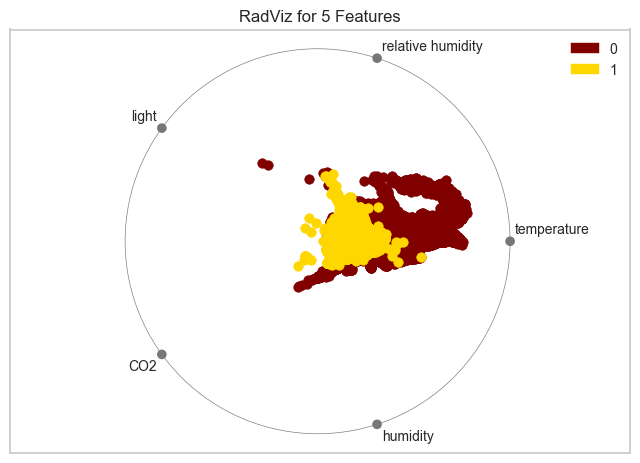

In [13]:
    from yellowbrick.features import radviz
    from yellowbrick.datasets import load_occupancy


    X, y = load_occupancy()
    visualizer = radviz(X, y, colors=["maroon", "gold"])

## PCA

A pca_decomposition is a projection of instances based on principal components. More about :doc:`api/features/pca`.

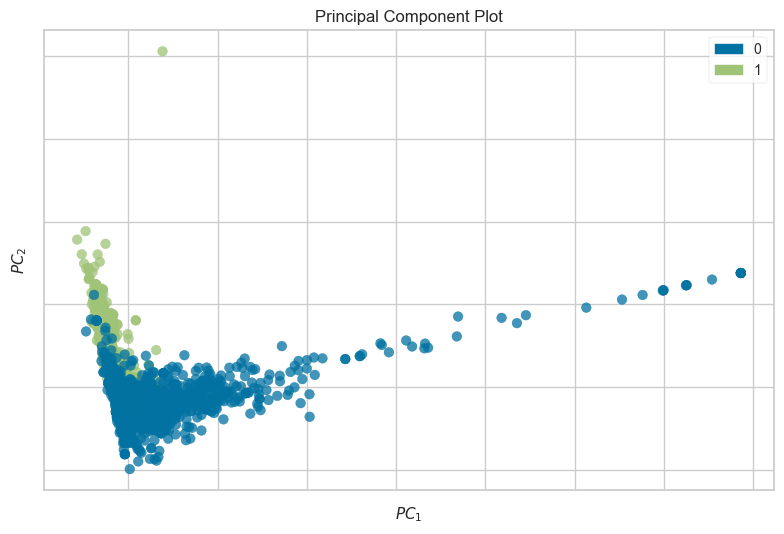

In [15]:
    from yellowbrick.datasets import load_spam
    from yellowbrick.features import pca_decomposition


    X, y = load_spam()
    visualizer = pca_decomposition(X, y)


## Manifold

The manifold_embedding plot is a high dimensional visualization with manifold learning, which can show nonlinear relationships in the features. More about :doc:`api/features/manifold`.

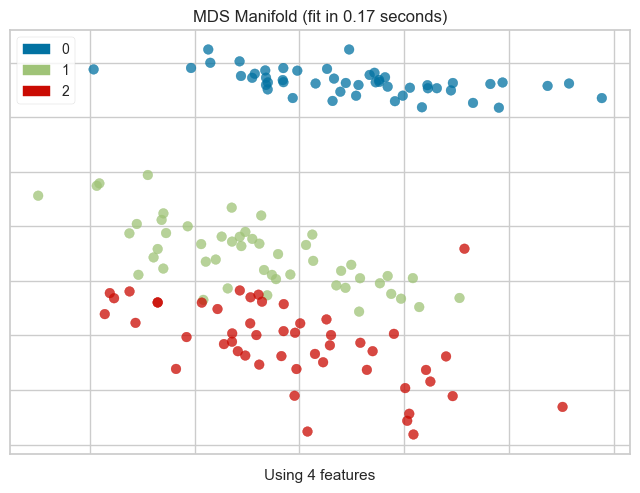

In [16]:

    from sklearn.datasets import load_iris
    from yellowbrick.features import manifold_embedding


    X, y = load_iris(return_X_y=True)
    visualizer = manifold_embedding(X, y)

# Classification

## Class Prediction Error

A class_prediction_error plot illustrates the error and support in a classification as a bar chart. More about :doc:`api/classifier/class_prediction_error`.

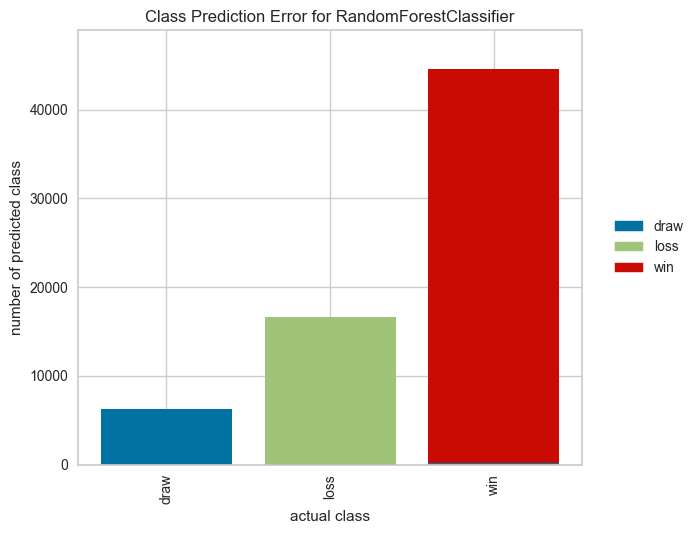

In [17]:
    from yellowbrick.datasets import load_game
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.ensemble import RandomForestClassifier
    from yellowbrick.classifier import class_prediction_error


    X, y = load_game()
    X = OneHotEncoder().fit_transform(X)
    visualizer = class_prediction_error(
        RandomForestClassifier(n_estimators=10), X, y
    )

## Classification Report

A classification_report is a visual representation of precision, recall, and F1 score. More about :doc:`api/classifier/classification_report`.

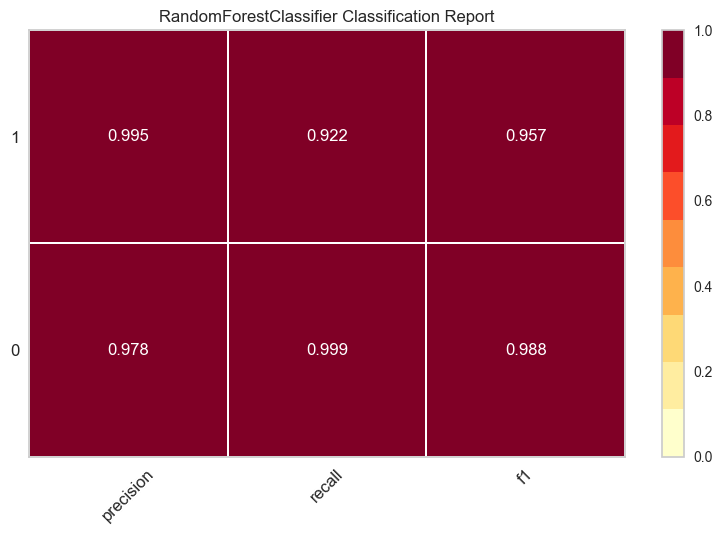

In [18]:
    from yellowbrick.datasets import load_credit
    from sklearn.ensemble import RandomForestClassifier
    from yellowbrick.classifier import classification_report


    X, y = load_credit()
    visualizer = classification_report(
        RandomForestClassifier(n_estimators=10), X, y
    )

## Confusion Matrix

A confusion_matrix is a visual description of per-class decision making. More about :doc:`api/classifier/confusion_matrix`.

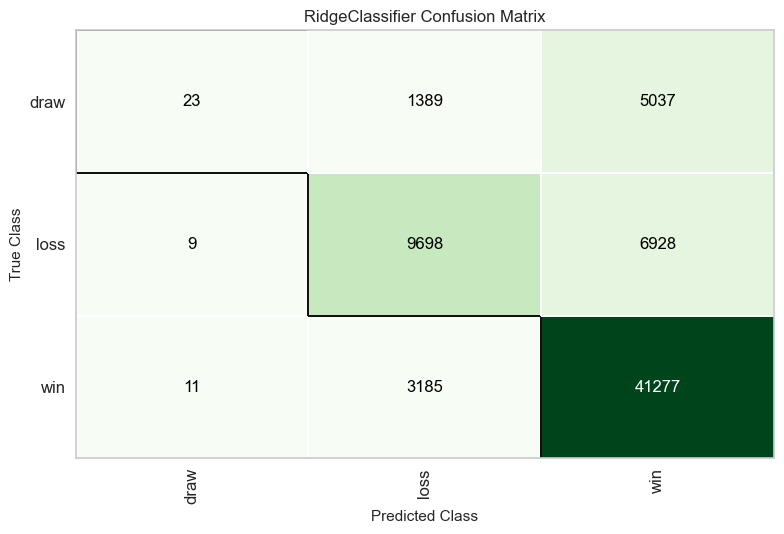

In [19]:
    from yellowbrick.datasets import load_game
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.linear_model import RidgeClassifier
    from yellowbrick.classifier import confusion_matrix


    X, y = load_game()
    X = OneHotEncoder().fit_transform(X)
    visualizer = confusion_matrix(RidgeClassifier(), X, y, cmap="Greens")

## Precision Recall

A precision_recall_curve shows the tradeoff between precision and recall for different probability thresholds. More about :doc:`api/classifier/prcurve`.

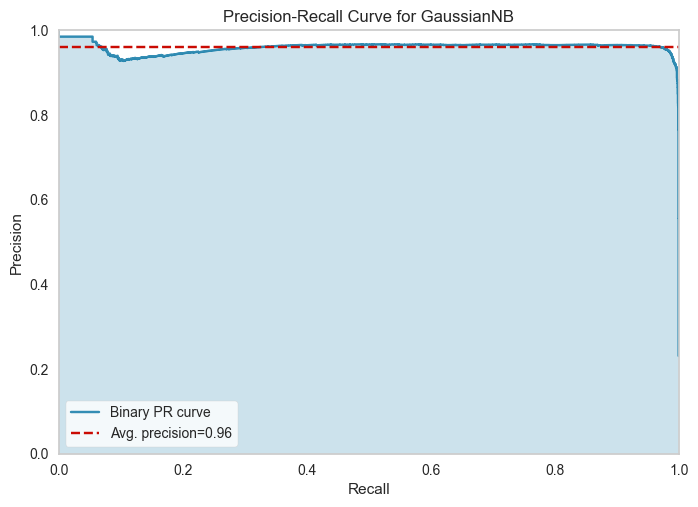

In [20]:
    from sklearn.naive_bayes import GaussianNB
    from yellowbrick.datasets import load_occupancy
    from yellowbrick.classifier import precision_recall_curve


    X, y = load_occupancy()
    visualizer = precision_recall_curve(GaussianNB(), X, y)

## ROCAUC

A roc_auc plot shows the receiver operator characteristics and area under the curve. More about :doc:`api/classifier/rocauc`.

c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


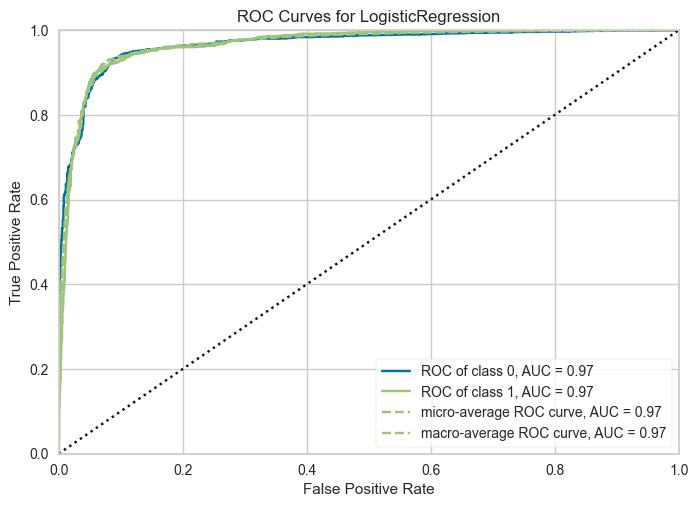

In [24]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
from sklearn.linear_model import LogisticRegression


X, y = load_spam()
visualizer = roc_auc(LogisticRegression(), X, y)

## Discrimination Threshold

A discrimination_threshold plot can help find a threshold that best separates binary classes. More about :doc:`api/classifier/threshold`.

c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\juani\anaconda3\envs\time_series\lib\site-packages\sklearn\linear_model\_log

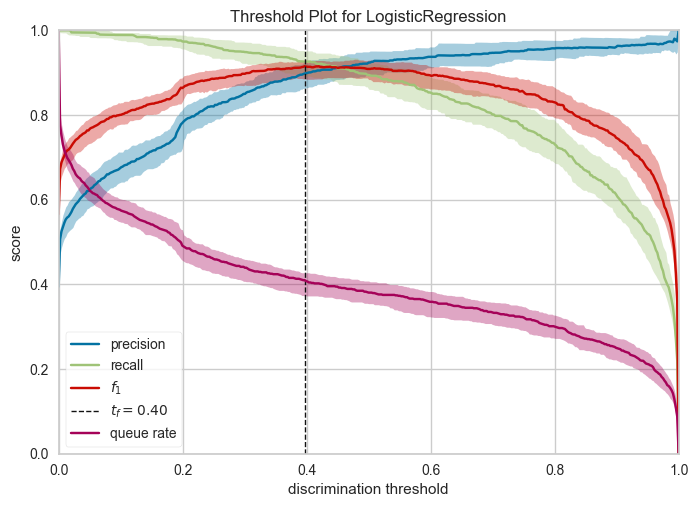

In [25]:
    from yellowbrick.classifier import discrimination_threshold
    from sklearn.linear_model import LogisticRegression
    from yellowbrick.datasets import load_spam

    X, y = load_spam()
    visualizer = discrimination_threshold(
        LogisticRegression(multi_class="auto", solver="liblinear"), X, y
    )

# Clustering

## Silhouette Scores

A silhouette_visualizer can help you select k by visualizing silhouette coefficient values. More about :doc:`api/cluster/silhouette`.

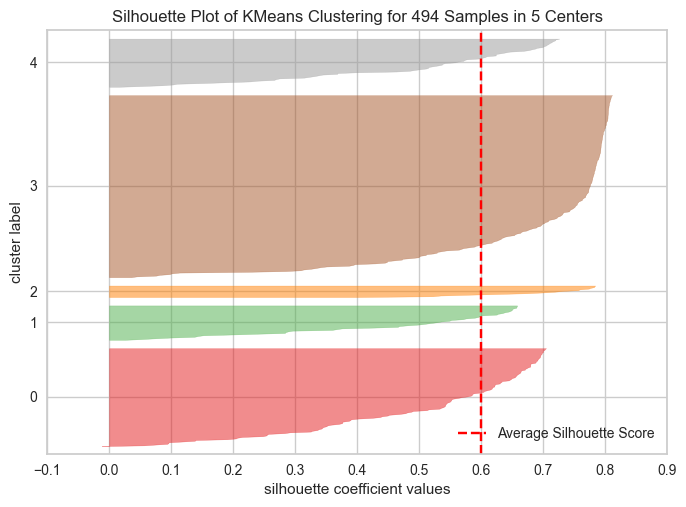

In [29]:
    from sklearn.cluster import KMeans
    from yellowbrick.datasets import load_nfl
    from yellowbrick.cluster import silhouette_visualizer

    X, y = load_nfl()
    visualizer = silhouette_visualizer(KMeans(5, random_state=42), X)

## Intercluster Distance

A intercluster_distance shows size and relative distance between clusters. More about :doc:`api/cluster/icdm`

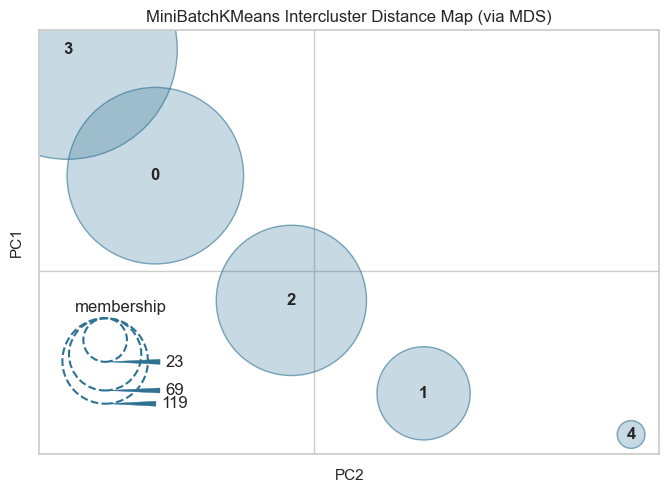

In [30]:
    from yellowbrick.datasets import load_nfl
    from sklearn.cluster import MiniBatchKMeans
    from yellowbrick.cluster import intercluster_distance


    X, y = load_nfl()
    visualizer = intercluster_distance(MiniBatchKMeans(5, random_state=777), X)

# Target Analysis


## ClassBalance

The class_balance plot can make it easier to see how the distribution of classes may affect the model. More about :doc:`api/target/class_balance`.

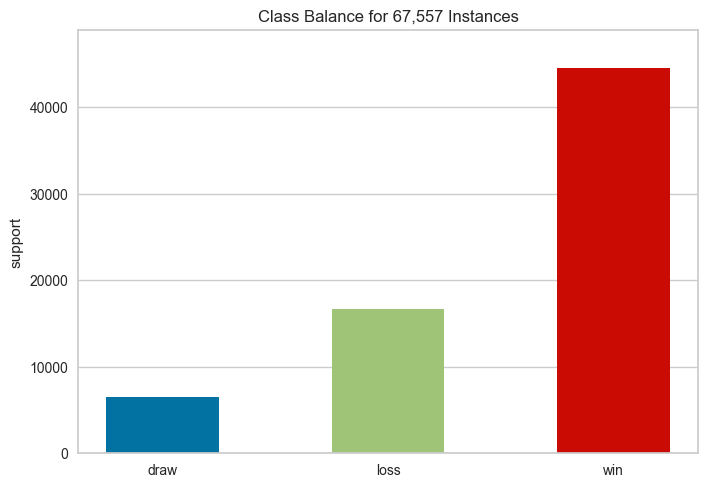

In [31]:
    from yellowbrick.datasets import load_game
    from yellowbrick.target import class_balance


    X, y = load_game()
    visualizer = class_balance(y, labels=["draw", "loss", "win"])